1)	Comet 3/I ATLAS



first we import our packages

In [1]:
from astroquery.jplhorizons import Horizons
import numpy as np
import matplotlib.pyplot as plt

Current distances from sun and some planets

In [47]:

obj_Sun = Horizons(id='3I', location='500@10')  # 500@10 is the code for the sun, this is sun-centered
vectors_sun = obj_Sun.vectors()['range']
print('sun =\n', vectors_sun[:5], '\n')

obj_Earth = Horizons(id='3I', location='500@399')  # 500@399 is for earth
vectors_earth = obj_Earth.vectors()['range']
print('earth =\n', vectors_earth[:5], '\n')

obj_mars = Horizons(id='3I', location='500@499')  # mars
vectors_mars = obj_mars.vectors()['range']
print('mars =\n', vectors_mars[:5], '\n')

obj_jupiter = Horizons(id='3I', location='500@599')  # jupiter
vectors_jupiter = obj_jupiter.vectors()['range']
print('jupiter =\n', vectors_jupiter[:5], '\n')

##prints the distance from these planets to 3/I ATLAS

sun =
       range      
        AU       
-----------------
5.745022731132543 

earth =
      range      
       AU       
----------------
5.72448607853473 

mars =
       range      
        AU       
-----------------
6.692705565103515 

jupiter =
       range       
        AU        
------------------
0.8105922141961944 



Closest approach to the sun and escape velocity calculation


In [ ]:
# measure the distance every day from the sun to 3I atlas from 2020 to 2030 
# and find the minimum
# 500@10 is the code for the sun,
# 
obj_Sun = Horizons(id='3I', location='500@10', epochs={'start':'2020-01-01', 'stop':'2030-01-01', 'step':'1d'}) 

# get the vectors from the data 
vectors_sun_closest = obj_Sun.vectors()

#extract the range column and place the data into an array
sun_distances = np.array(vectors_sun_closest['range'], dtype=float) 

#get the minimum value in our array
min_dist_sun = sun_distances.min()

print('3I/ ATLAS minimum distance from the sun =\n',min_dist_sun, 'au')
print(min_dist_sun*1.496e+8, 'km')



3I/ ATLAS minimum distance from the sun =
 1.356562636637138 au
202941770.44091582 km


In [7]:
# now to calculate the escape velocity required to escape the suns gravitational pull at this altititude
# using equation v = sqrt(2GM/r)
# M is mass of sun, G is constant, r is radius from center of sun to object
M_sun = 1.989E30 #mass of sun
G = 6.6743E-11 # Gravitational constant
r = min_dist_sun * 1.496e+11 # distance converted from AU to meters

V_escape = np.sqrt(2*G*M_sun/r)
print('escape velocity at 3I/ATLAS closest point is \n', V_escape)

escape velocity at 3I/ATLAS closest point is 
 36170.08495579899


Closest approaches

    Closest approach to earth

In [ ]:
# measure the distance every day from earth to 3I atlas from 2020 to 2030 
# and find the minimum
# 500@10 is the code for the earth,
# 
obj_Earth = Horizons(id='3I', location='500@399', epochs={'start':'2020-01-01', 'stop':'2030-01-01', 'step':'1d'}) 

# get the vectors from the data 
vectors_Earth_closest = obj_Earth.vectors()

#extract the range column and place the data into an array
Earth_distances = np.array(vectors_Earth_closest['range'], dtype=float) 

#get the minimum value in our array
min_dist_Earth =Earth_distances.min()

print('3I/ ATLAS minimum distance from Earth =\n',min_dist_Earth, 'au')
print(min_dist_Earth*1.496e+8, 'km')



3I/ ATLAS minimum distance from Earth =
 1.797751915939378 au
268943686.624531 km


    Closest approach to Jupiter

In [ ]:
# measure the distance every day from Jupiter to 3I atlas from 2020 to 2030 
# and find the minimum
# 500@599 is the code for the Jupiter,
# 
obj_Jupiter = Horizons(id='3I', location='500@599', epochs={'start':'2020-01-01', 'stop':'2030-01-01', 'step':'1d'}) 

# get the vectors from the data 
vectors_Jupiter_closest = obj_Jupiter.vectors()

#extract the range column and place the data into an array
Jupiter_distances = np.array(vectors_Jupiter_closest['range'], dtype=float) 

#get the minimum value in our array
min_dist_Jupiter =Jupiter_distances.min()

print('3I/ ATLAS minimum distance from Jupiter =\n',min_dist_Jupiter, 'au')
print(min_dist_Jupiter*1.496e+8, 'km')



3I/ ATLAS minimum distance from Jupiter =
 0.3587972476023516 au
53676068.241311796 km


    Closest approach to mars

In [ ]:
# measure the distance every day from Mars to 3I atlas from 2020 to 2030 
# and find the minimum
# 500@499 is the code for the Mars,
# 
obj_Mars = Horizons(id='3I', location='500@499', epochs={'start':'2020-01-01', 'stop':'2030-01-01', 'step':'1d'}) 

# get the vectors from the data 
vectors_Mars_closest = obj_Mars.vectors()

#extract the range column and place the data into an array
Mars_distances = np.array(vectors_Mars_closest['range'], dtype=float) 

#get the minimum value in our array
min_dist_Mars =Mars_distances.min()

print('3I/ ATLAS minimum distance from Mars =\n',min_dist_Mars, 'au')
print(min_dist_Mars*1.496e+8, 'km')


3I/ ATLAS minimum distance from Mars =
 0.1938967240891711 au
29006949.92374 km


Trajectory

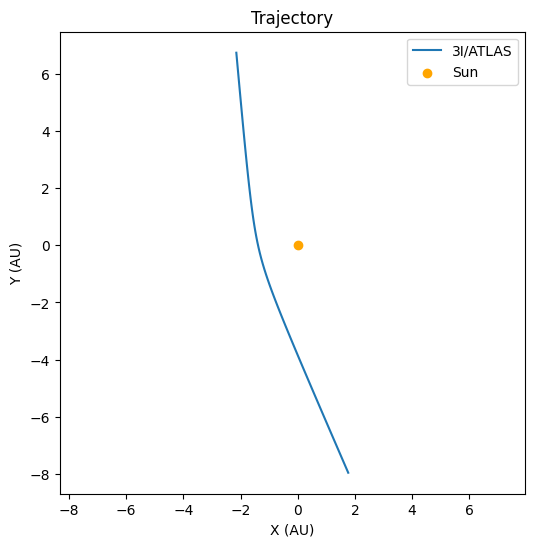

In [ ]:
obj = Horizons(id='3I', location='500@10', epochs={'start':'2025-03-15', 'stop':'2026-05-15', 'step':'5d'})

vec = obj.vectors()

# Convert to DataFrame
df = vec.to_pandas()

# Positions in AU
x, y, z = df['x'], df['y'], df['z']

# Plot trajectory in ecliptic plane
plt.figure(figsize=(6,6))
plt.plot(x, y, label='3I/ATLAS')
plt.scatter(0, 0, color='orange', label='Sun')
plt.xlabel('X (AU)')
plt.ylabel('Y (AU)')
plt.legend()
plt.title('Trajectory')
plt.axis('equal')
plt.show()

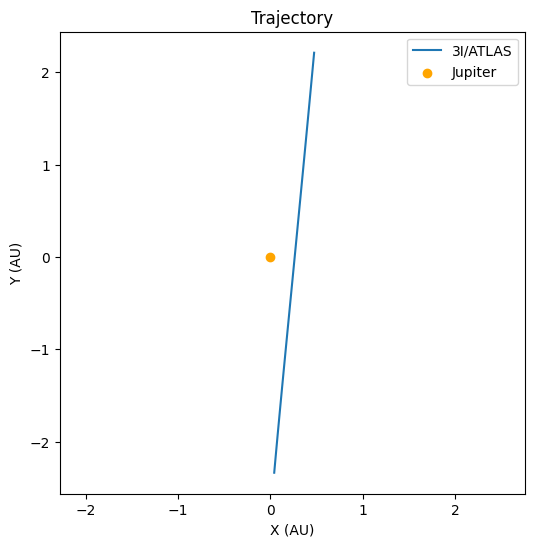

In [2]:



obj = Horizons(id='3I', location='500@599', epochs={'start':'2026-01-15', 'stop':'2026-05-15', 'step':'5d'})

vec = obj.vectors()

# Convert to DataFrame
df = vec.to_pandas()

# Positions in AU
x, y, z = df['x'], df['y'], df['z']

# Plot trajectory in ecliptic plane
plt.figure(figsize=(6,6))
plt.plot(x, y, label='3I/ATLAS')
plt.scatter(0, 0, color='orange', label='Jupiter')
plt.xlabel('X (AU)')
plt.ylabel('Y (AU)')
plt.legend()
plt.title('Trajectory')
plt.axis('equal')
plt.show()

distance over time

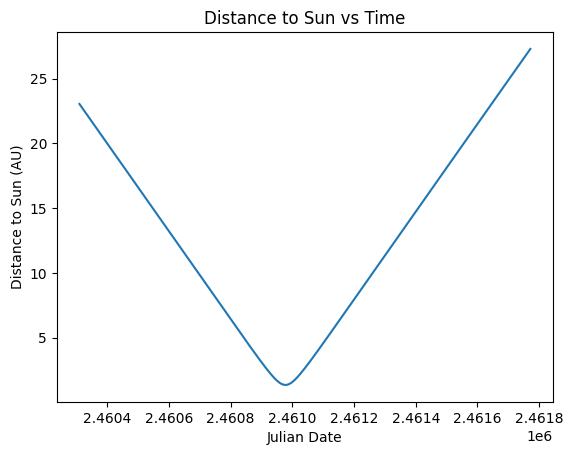

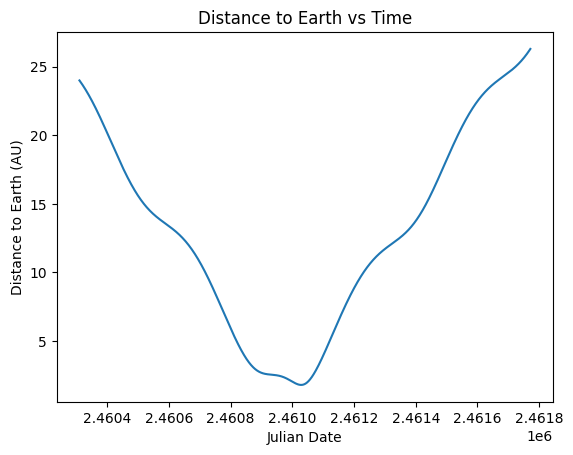

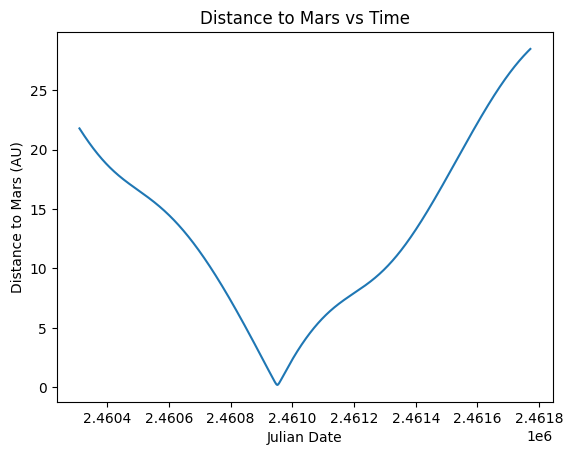

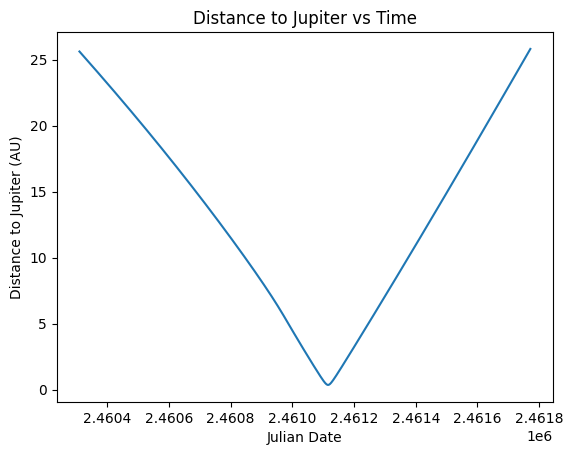

In [54]:
# sun-centered distance
obj_Sun = Horizons(id='3I', location='500@10', epochs={'start':'2024-01-01', 'stop':'2028-01-01', 'step':'1d'})

eph = obj_Sun.ephemerides()

df_e = eph.to_pandas()

plt.plot(df_e['datetime_jd'], df_e['delta'])
plt.ylabel('Distance to Sun (AU)')
plt.xlabel('Julian Date')
plt.title('Distance to Sun vs Time')
plt.show()

# Earth-centered distance
obj_earth = Horizons(id='3I', location='500@399', epochs={'start':'2024-01-01', 'stop':'2028-01-01', 'step':'1d'})

eph = obj_earth.ephemerides()

df_e = eph.to_pandas()

plt.plot(df_e['datetime_jd'], df_e['delta'])
plt.ylabel('Distance to Earth (AU)')
plt.xlabel('Julian Date')
plt.title('Distance to Earth vs Time')
plt.show()

# Mars-centered distance
obj_Mars = Horizons(id='3I', location='500@499', epochs={'start':'2024-01-01', 'stop':'2028-01-01', 'step':'1d'})

eph = obj_Mars.ephemerides()

df_e = eph.to_pandas()

plt.plot(df_e['datetime_jd'], df_e['delta'])
plt.ylabel('Distance to Mars (AU)')
plt.xlabel('Julian Date')
plt.title('Distance to Mars vs Time')
plt.show()

# Jupiter-centered distance
obj_Jupiter = Horizons(id='3I', location='500@599', epochs={'start':'2024-01-01', 'stop':'2028-01-01', 'step':'1d'})

eph = obj_Jupiter.ephemerides()

df_e = eph.to_pandas()

plt.plot(df_e['datetime_jd'], df_e['delta'])
plt.ylabel('Distance to Jupiter (AU)')
plt.xlabel('Julian Date')
plt.title('Distance to Jupiter vs Time')
plt.show()